# Module 7: Further Markov Chain Based Models

This module collects applied models that use ideas from the previous Markov chain modules. They show how stochastic process ideas appear in different applications: failure, survival, system reliability, buffer growth, and queue stability.

## Libraries




In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
FIGSIZE = (8, 4.5)
SMALL_FIGSIZE = (8, 3.5)
SUBPLOT_FIGSIZE = (8, 9)

HIST_ALPHA = 0.65
OVERLAP_ALPHA = 0.45

plt.rcParams["figure.figsize"] = FIGSIZE
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = False

plt.rcParams["lines.markersize"] = 4

# Random generator
rng = np.random.default_rng()

## Part A: Reliability and life length models

## Example 1: The life length process

The random variable $T$ is the life length of the component. The process $X(t)$ records whether the component is still working at time $t$.

The state space is $E=\{0,1\}$. State $1$ means working, and state $0$ means failed. The life length process is

$$
X(t)=
\begin{cases}
1, & t<T,\\
0, & t\geq T.
\end{cases}
$$

In the simulation below, we draw several random life lengths and plot the corresponding paths. Each path stays at $1$ until its failure time, then jumps to $0$ and remains there.

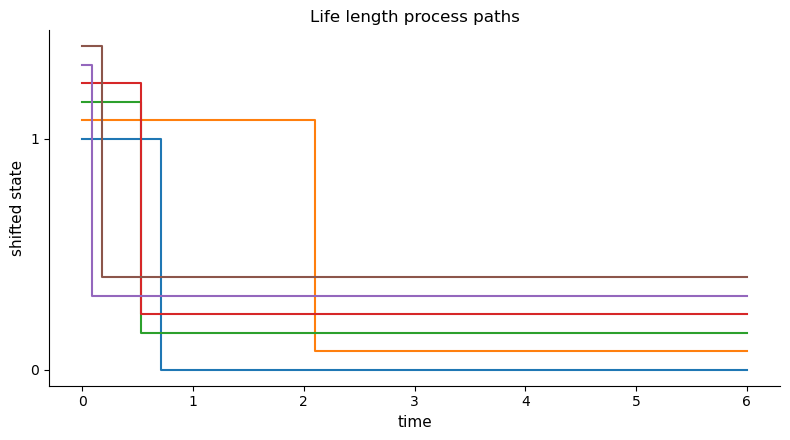

In [3]:
# Exponential failure rate
lam = 0.8

# Number of paths to display
n_paths = 6

# Time interval and grid
T_max = 6.0
n_grid = 400
t_grid = np.linspace(0, T_max, n_grid)

# Random generator
rng = np.random.default_rng()

# Simulate life lengths
lifetimes = rng.exponential(
    scale=1 / lam,
    size=n_paths
)

plt.figure(figsize=FIGSIZE)

for i, T in enumerate(lifetimes):
    path = (t_grid < T).astype(int)

    plt.step(
        t_grid,
        path + 0.08 * i,
        where="post"
    )

plt.xlabel("time")
plt.ylabel("shifted state")
plt.title("Life length process paths")
plt.yticks([0, 1], [0, 1])
plt.tight_layout()
plt.show()

The plot shows several sample paths of the life length process. Each component starts in state $1$, jumps to state $0$ at a random failure time, and then remains there.

Thus, the model has only one possible jump: from working to failed. This is different from the continuous time Markov chain examples, where the process may move repeatedly between states. The small vertical shifts are only for visualization.


For an exponential life length with rate $\lambda$, the survival probability is

$$
P(T>t)=e^{-\lambda t}.
$$

Since $X(t)=1$ exactly when the component is still working, this is also the probability that $X(t)=1$.

We now repeat the experiment many times and compare the simulated survival probability with the theoretical curve. This changes the focus from individual paths to a probability curve.

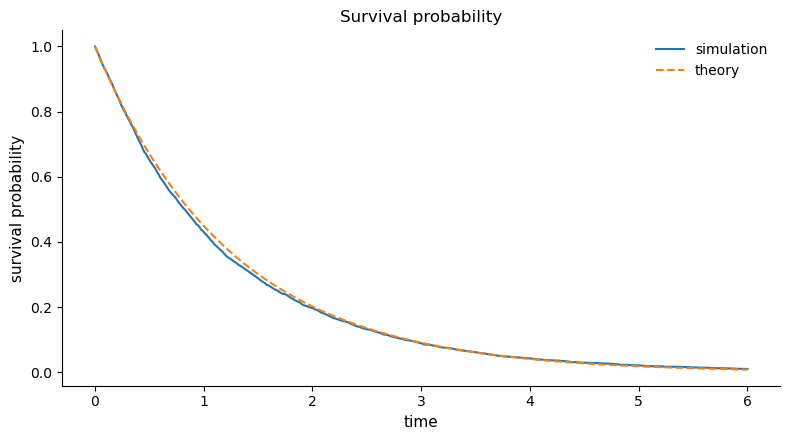

In [4]:
# Number of repeated simulations
n_runs = 5000

# Random generator
rng = np.random.default_rng()

# Simulate many life lengths
lifetimes_many = rng.exponential(
    scale=1 / lam,
    size=n_runs
)

# Empirical survival probability at each time point
survival_empirical = np.array([
    np.mean(lifetimes_many > t)
    for t in t_grid
])

# Theoretical survival probability
survival_theory = np.exp(-lam * t_grid)

plt.figure(figsize=FIGSIZE)

plt.plot(
    t_grid,
    survival_empirical,
    label="simulation"
)

plt.plot(
    t_grid,
    survival_theory,
    linestyle="--",
    label="theory"
)

plt.xlabel("time")
plt.ylabel("survival probability")
plt.title("Survival probability")
plt.legend()
plt.tight_layout()
plt.show()

The horizontal axis is time, and the vertical axis is the probability that the component is still working. The simulated curve is close to the theoretical survival function $e^{-\lambda t}$, and both decrease over time as more components fail.


### Task 1

Change the failure rate from $\lambda=0.8$ to $\lambda=1.2$.

Simulate a new survival curve and plot it together with the previous case $\lambda=0.8$ in the same figure.

What happens to the survival probability when the failure rate becomes larger?

In [5]:
# Simulate and compare two survival curves.

# Set the old failure rate and the new failure rate.


### Solution

A larger failure rate means a shorter average life length. For an exponential life length, the mean is $1/\lambda$.

When $\lambda=0.8$, the mean life length is $1/0.8=1.25$.

When $\lambda=1.2$, the mean life length is $1/1.2\approx 0.83$.

Therefore, the survival curve for $\lambda=1.2$ should decrease faster.

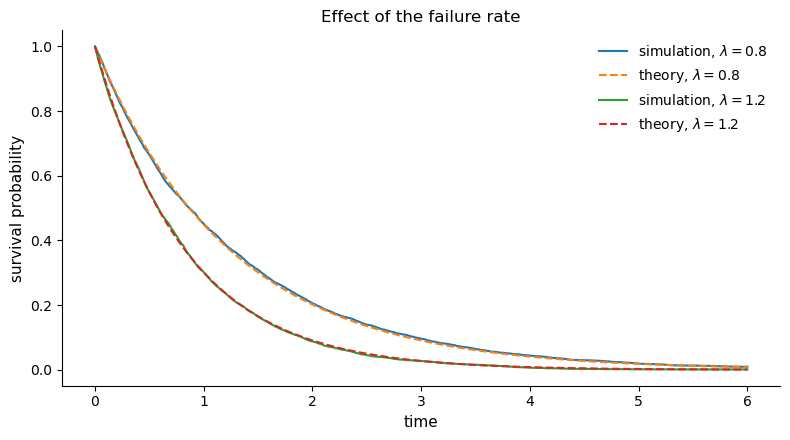

In [6]:
# Solution to Task 1

# Failure rates
lam_old = 0.8
lam_new = 1.2

# Number of repeated simulations
n_runs = 5000

# Random generator
rng = np.random.default_rng()

# Simulate life lengths for lambda = 0.8
lifetimes_old = rng.exponential(
    scale=1 / lam_old,
    size=n_runs
)

# Simulate life lengths for lambda = 1.2
lifetimes_new = rng.exponential(
    scale=1 / lam_new,
    size=n_runs
)

# Empirical survival probabilities
survival_old = np.array([
    np.mean(lifetimes_old > t)
    for t in t_grid
])

survival_new = np.array([
    np.mean(lifetimes_new > t)
    for t in t_grid
])

# Theoretical survival probabilities
survival_old_theory = np.exp(-lam_old * t_grid)
survival_new_theory = np.exp(-lam_new * t_grid)

plt.figure(figsize=FIGSIZE)

plt.plot(
    t_grid,
    survival_old,
    label=r"simulation, $\lambda=0.8$"
)

plt.plot(
    t_grid,
    survival_old_theory,
    linestyle="--",
    label=r"theory, $\lambda=0.8$"
)

plt.plot(
    t_grid,
    survival_new,
    label=r"simulation, $\lambda=1.2$"
)

plt.plot(
    t_grid,
    survival_new_theory,
    linestyle="--",
    label=r"theory, $\lambda=1.2$"
)

plt.xlabel("time")
plt.ylabel("survival probability")
plt.title("Effect of the failure rate")
plt.legend()
plt.tight_layout()
plt.show()

The curve for $\lambda=1.2$ decreases faster than the curve for $\lambda=0.8$.

This means that a larger failure rate gives shorter life lengths on average. The comparison also shows that the simulated survival curves are close to the theoretical curves.

## Example 2: Series and parallel systems

We now build a system from two independent components. The random variables $T_1$ and $T_2$ are the life lengths of the two components.

A series system works only when both components are working. It fails as soon as the first component fails. Its life length is

$$
T_{\mathrm{ser}}=\min(T_1,T_2).
$$

A parallel system works as long as at least one component is still working. It fails only when both components have failed. Its life length is

$$
T_{\mathrm{par}}=\max(T_1,T_2).
$$

This example compares the two system designs by simulation. We expect the series system to fail earlier and the parallel system to last longer.

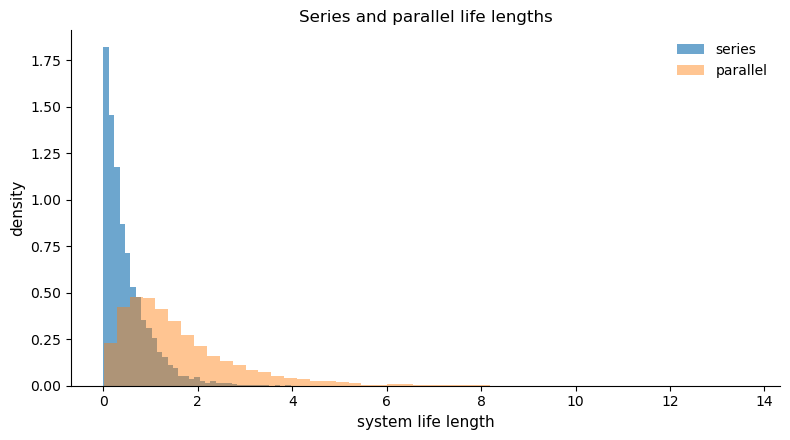

In [7]:
# Failure rates of the two components
lam1 = 0.8
lam2 = 1.2

# Number of repeated simulations
n_runs = 10000

# Random generator
rng = np.random.default_rng()

# Simulate independent component life lengths
T1 = rng.exponential(
    scale=1 / lam1,
    size=n_runs
)

T2 = rng.exponential(
    scale=1 / lam2,
    size=n_runs
)

# System life lengths
T_ser = np.minimum(T1, T2)
T_par = np.maximum(T1, T2)

plt.figure(figsize=FIGSIZE)

plt.hist(
    T_ser,
    bins=50,
    density=True,
    alpha=HIST_ALPHA,
    label="series"
)

plt.hist(
    T_par,
    bins=50,
    density=True,
    alpha=OVERLAP_ALPHA,
    label="parallel"
)

plt.xlabel("system life length")
plt.ylabel("density")
plt.title("Series and parallel life lengths")
plt.legend()
plt.tight_layout()
plt.show()

In a series system, the life length is concentrated closer to zero because the system fails as soon as one component fails.

In a parallel system, the life length has more mass at larger values because the system continues working until both components have failed. Thus, the same component life lengths can lead to different system behaviour, depending on the system structure.


We can also compare the reliability functions. At time $t$, the reliability is the probability that the system is still working.

For independent components, the series reliability is

$$
R_{\mathrm{ser}}(t)=R_1(t)R_2(t).
$$

The parallel reliability is

$$
R_{\mathrm{par}}(t)=1-(1-R_1(t))(1-R_2(t)).
$$

The next plot compares simulated reliability curves with these theoretical formulas.

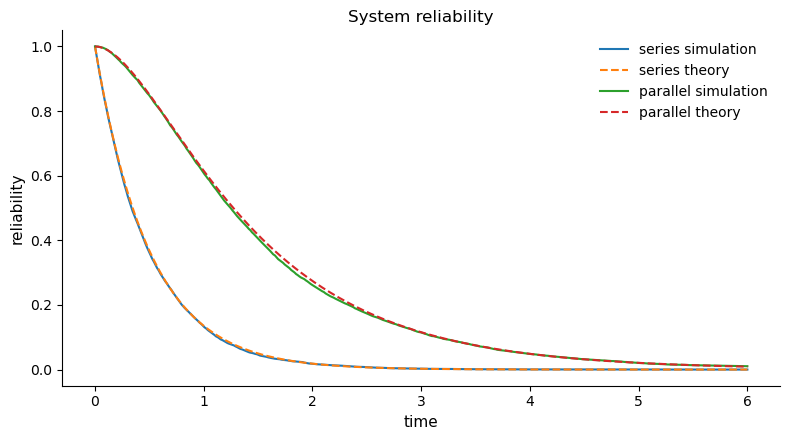

In [8]:
# Time grid for reliability curves
T_max = 6.0
t_grid = np.linspace(0, T_max, 400)

# Empirical reliability curves
R_ser_emp = np.array([
    np.mean(T_ser > t)
    for t in t_grid
])

R_par_emp = np.array([
    np.mean(T_par > t)
    for t in t_grid
])

# Component reliabilities
R1 = np.exp(-lam1 * t_grid)
R2 = np.exp(-lam2 * t_grid)

# Theoretical system reliabilities
R_ser_theory = R1 * R2
R_par_theory = 1 - (1 - R1) * (1 - R2)

plt.figure(figsize=FIGSIZE)

plt.plot(
    t_grid,
    R_ser_emp,
    label="series simulation"
)

plt.plot(
    t_grid,
    R_ser_theory,
    linestyle="--",
    label="series theory"
)

plt.plot(
    t_grid,
    R_par_emp,
    label="parallel simulation"
)

plt.plot(
    t_grid,
    R_par_theory,
    linestyle="--",
    label="parallel theory"
)

plt.xlabel("time")
plt.ylabel("reliability")
plt.title("System reliability")
plt.legend()
plt.tight_layout()
plt.show()

The series reliability is lower because both components must still be working for the system to work.

The parallel reliability is higher because the system can continue working after one component has failed. The simulated curves are close to the theoretical curves, showing that the simulation agrees with the formulas for independent components.

### Task 2

Use the simulated component life lengths `T1` and `T2`. Create `T_ser_task`, the life lengths of the series system, and `T_par_task`, the life lengths of the parallel system. Then compute the mean life length of each system. Which system has the larger mean life length?


In [9]:
# Compute the series and parallel system life lengths.

# Use T1 and T2.


### Solution

The series system fails at the first component failure, so its life length is the minimum of $T_1$ and $T_2$.

The parallel system fails only after both components have failed, so its life length is the maximum of $T_1$ and $T_2$.

In [10]:
# Solution to Task 2

# Series and parallel system life lengths
T_ser_task = np.minimum(T1, T2)
T_par_task = np.maximum(T1, T2)

# Mean life lengths
mean_ser_task = np.mean(T_ser_task)
mean_par_task = np.mean(T_par_task)

print("Mean series lifetime:")
print(mean_ser_task)

print()
print("Mean parallel lifetime:")
print(mean_par_task)

Mean series lifetime:
0.49439206647942463

Mean parallel lifetime:
1.5643142584951064


The parallel system has the larger mean life length.

This matches the reliability curves. The parallel system keeps working as long as at least one component is still working, while the series system stops as soon as one component fails.

## Example 3: Hazard rates

The previous examples used life lengths and reliability curves. We now look at another way to describe life length distributions: the hazard rate.

The survival function is

$$
R(t)=P(T>t).
$$

The hazard rate describes the instantaneous failure risk at time $t$, given that the component has survived up to time $t$:

$$
\lambda(t)=\frac{f(t)}{R(t)}.
$$

The hazard rate describes how the failure risk changes over time. It may be constant, increasing, or decreasing, depending on whether the component becomes equally likely, more likely, or less likely to fail as time passes.

Here we compare these three cases using simple life length distributions.


In [11]:
def survival_exponential(t, lam=1.0):
    """
    Survival function of an exponential distribution.
    """
    return np.exp(-lam * t)

def hazard_exponential(t, lam=1.0):
    """
    Hazard rate of an exponential distribution.
    """
    return lam * np.ones_like(t)

def survival_weibull(t, alpha=1.0, beta=1.5):
    """
    Survival function of a Weibull distribution.
    """
    return np.exp(-(t / alpha) ** beta)

def hazard_weibull(t, alpha=1.0, beta=1.5):
    """
    Hazard rate of a Weibull distribution.
    """
    return (beta / alpha) * (t / alpha) ** (beta - 1)

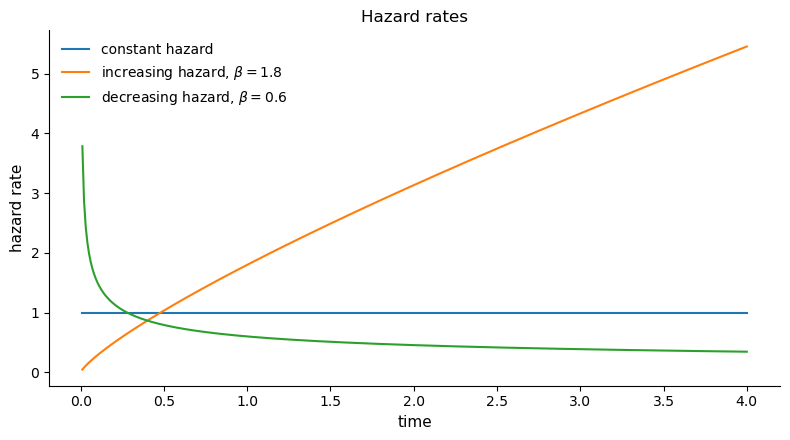

In [12]:
# Time grid
t = np.linspace(0.01, 4, 400)

# Hazard rates
haz_constant = hazard_exponential(t, lam=1.0)
haz_increasing = hazard_weibull(t, alpha=1.0, beta=1.8)
haz_decreasing = hazard_weibull(t, alpha=1.0, beta=0.6)

plt.figure(figsize=FIGSIZE)

plt.plot(
    t,
    haz_constant,
    label="constant hazard"
)

plt.plot(
    t,
    haz_increasing,
    label=r"increasing hazard, $\beta=1.8$"
)

plt.plot(
    t,
    haz_decreasing,
    label=r"decreasing hazard, $\beta=0.6$"
)

plt.xlabel("time")
plt.ylabel("hazard rate")
plt.title("Hazard rates")
plt.legend()
plt.tight_layout()
plt.show()

The exponential distribution has a constant hazard rate, so the failure risk does not depend on age.

A Weibull model with $\beta>1$ has an increasing hazard rate and can describe aging. A Weibull model with $\beta<1$ has a decreasing hazard rate and can describe early failures. This comparison is about failure risk over time, not sample paths.

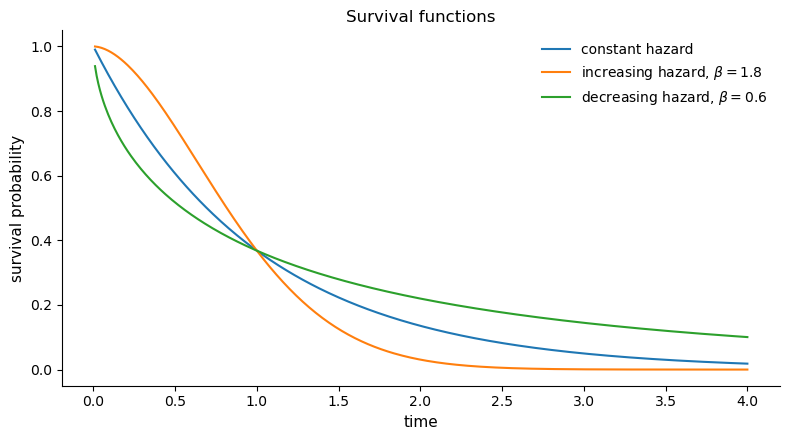

In [13]:
# Survival functions
R_constant = survival_exponential(t, lam=1.0)
R_increasing = survival_weibull(t, alpha=1.0, beta=1.8)
R_decreasing = survival_weibull(t, alpha=1.0, beta=0.6)

plt.figure(figsize=FIGSIZE)

plt.plot(
    t,
    R_constant,
    label="constant hazard"
)

plt.plot(
    t,
    R_increasing,
    label=r"increasing hazard, $\beta=1.8$"
)

plt.plot(
    t,
    R_decreasing,
    label=r"decreasing hazard, $\beta=0.6$"
)

plt.xlabel("time")
plt.ylabel("survival probability")
plt.title("Survival functions")
plt.legend()
plt.tight_layout()
plt.show()

The survival curves give the probability that the component is still working at time $t$. All curves decrease over time, but the shapes differ: the increasing hazard model drops more sharply later, while the decreasing hazard model drops more sharply near the beginning.

The comparison also separates two ideas. Survival probability describes the chance of still working at time $t$, while the hazard rate describes the failure risk at time $t$, given survival up to that time.


### Optional: A bathtub shaped hazard rate

A common qualitative shape in reliability modelling is the bathtub shaped hazard rate.

The idea is that different failure mechanisms dominate at different ages:

- early failures decrease with time;
- random operating risk is approximately constant;
- aging failures increase with time.

We model the total hazard rate as the sum of three components:

$$
\lambda(t)=\lambda_{\mathrm{early}}(t)+\lambda_{\mathrm{random}}(t)+\lambda_{\mathrm{aging}}(t).
$$

This is not meant to be a fitted model. It is a visual example that shows how a more complicated hazard rate can be built from simpler parts.

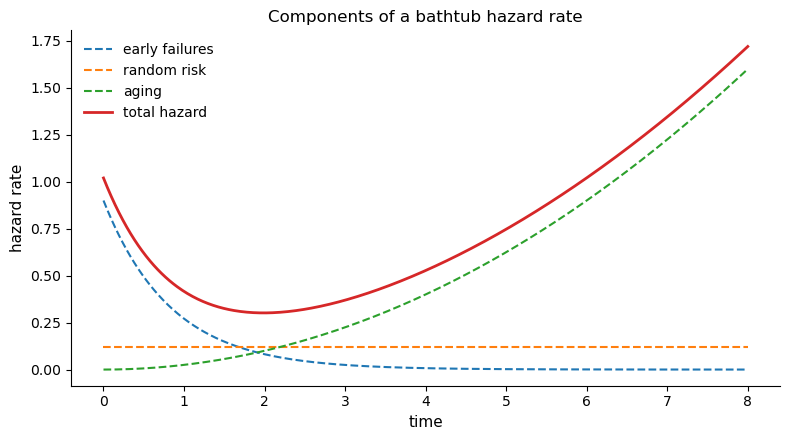

In [14]:
# Time grid
t_bath = np.linspace(0, 8, 500)

# Three components of the hazard rate
haz_early = 0.9 * np.exp(-1.2 * t_bath)
haz_random = 0.12 * np.ones_like(t_bath)
haz_aging = 0.025 * t_bath**2

# Total bathtub hazard rate
haz_total = haz_early + haz_random + haz_aging

plt.figure(figsize=FIGSIZE)

plt.plot(
    t_bath,
    haz_early,
    linestyle="--",
    label="early failures"
)

plt.plot(
    t_bath,
    haz_random,
    linestyle="--",
    label="random risk"
)

plt.plot(
    t_bath,
    haz_aging,
    linestyle="--",
    label="aging"
)

plt.plot(
    t_bath,
    haz_total,
    linewidth=2,
    label="total hazard"
)

plt.xlabel("time")
plt.ylabel("hazard rate")
plt.title("Components of a bathtub hazard rate")
plt.legend()
plt.tight_layout()
plt.show()

The dashed curves represent three sources of failure risk: early failures, random failures, and aging. Early failure risk is high at the beginning and then decreases, random failure risk is constant, and aging risk increases with time.

The solid curve is the total hazard rate. It first decreases, then stays nearly flat, and finally increases, giving the bathtub shape. This shows how one hazard curve can combine several different failure mechanisms.


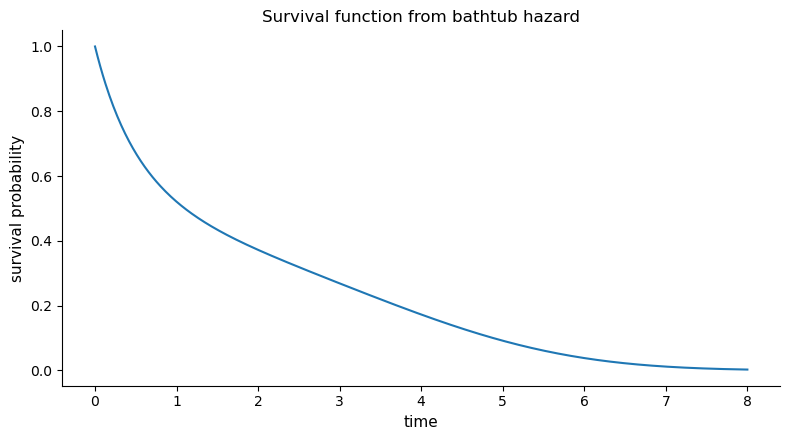

In [15]:
# Start the cumulative hazard at zero
cum_hazard = np.zeros_like(t_bath)

# Integrate each interval with the trapezoidal rule
cum_hazard[1:] = np.cumsum(
    0.5 * (haz_total[:-1] + haz_total[1:]) * np.diff(t_bath)
)

# Survival function corresponding to the total hazard
survival_bath = np.exp(-cum_hazard)

plt.figure(figsize=FIGSIZE)

plt.plot(
    t_bath,
    survival_bath
)

plt.xlabel("time")
plt.ylabel("survival probability")
plt.title("Survival function from bathtub hazard")
plt.tight_layout()
plt.show()

The survival function is computed from the cumulative hazard:

$$
R(t)=\exp\left(-\int_0^t \lambda(s)\,ds\right).
$$

Even when the hazard rate is not monotone, the survival function is still decreasing. The hazard rate describes the instantaneous failure risk, while the survival function describes the probability that the system is still working.

## Part B: Buffer and queue models

The previous examples focused on reliability. The state represented whether a component or system was still working, and the main quantities were life lengths, survival probabilities, and failure rates.

We now turn to buffer and queue models. Here the state describes the number of packets or customers in the system, rather than whether a component has failed.


## Example 4: A discrete time buffer

We now move from reliability models to buffer models.

A buffer stores packets before they are transmitted. The state is no longer working or failed. Instead, the state is the number of packets waiting in the buffer.

Let $Q_n$ be the buffer size after time slot $n$. During each slot, new packets arrive and at most one packet can be transmitted.

If $A_{n+1}$ is the number of new arrivals during slot $n+1$, the update rule is

$$
Q_{n+1}=Q_n+A_{n+1}-\mathbf{1}_{\{Q_n+A_{n+1}\geq 1\}}.
$$

The indicator term means that one packet is transmitted if at least one packet is available during the slot. The update uses a fixed event order: arrivals occur first, one packet is then transmitted if possible, and $Q_{n+1}$ records the packets that remain. A different event order would define a different discrete time model.

### Bernoulli arrivals

We first consider Bernoulli arrivals, where each time slot contains either one arriving packet or no arriving packet.

Starting from an empty buffer, the simulated path stays at zero. Under this update rule, at most one packet arrives in each slot and at most one packet can be transmitted, so the buffer cannot build up from zero.






In [16]:
def simulate_bernoulli_buffer(n_steps, arrival_prob, rng):
    """
    Simulate a discrete time buffer with Bernoulli arrivals.
    """

    Q = np.zeros(n_steps + 1, dtype=int)

    for n in range(n_steps):
        # New arrivals during the slot
        arrival = rng.binomial(1, arrival_prob)

        # At most one packet can be transmitted
        service = int(Q[n] + arrival >= 1)

        # Buffer update
        Q[n + 1] = Q[n] + arrival - service

    return Q

In [17]:
# Check the Bernoulli buffer
n_steps = 20
arrival_prob = 0.7

rng = np.random.default_rng()

Q_bernoulli = simulate_bernoulli_buffer(
    n_steps,
    arrival_prob,
    rng
)

print("Bernoulli buffer path:")
print(Q_bernoulli)

print()
print("Maximum buffer size:")
print(np.max(Q_bernoulli))

Bernoulli buffer path:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Maximum buffer size:
0


The printed path stays at zero. With Bernoulli arrivals, at most one packet arrives in a slot. Since at most one packet can also be transmitted, the buffer does not accumulate when it starts empty.

For a more informative simulation, we now use batch arrivals.

### Batch arrivals

A buffer becomes more interesting when several packets can arrive during the same slot.

We now use geometric batch arrivals on $\{0,1,2,\ldots\}$. Smaller values of $p$ give larger batches on average. Since at most one packet can be transmitted per slot, larger batches can make the buffer grow.

In [18]:
def simulate_batch_buffer(n_steps, p, rng):
    """
    Simulate a discrete time buffer with geometric batch arrivals.
    """

    Q = np.zeros(n_steps + 1, dtype=int)

    for n in range(n_steps):
        # Geometric random variable shifted to values 0, 1, 2, ...
        arrival = rng.geometric(p) - 1

        # At most one packet can be transmitted
        service = int(Q[n] + arrival >= 1)

        # Buffer update
        Q[n + 1] = Q[n] + arrival - service

    return Q

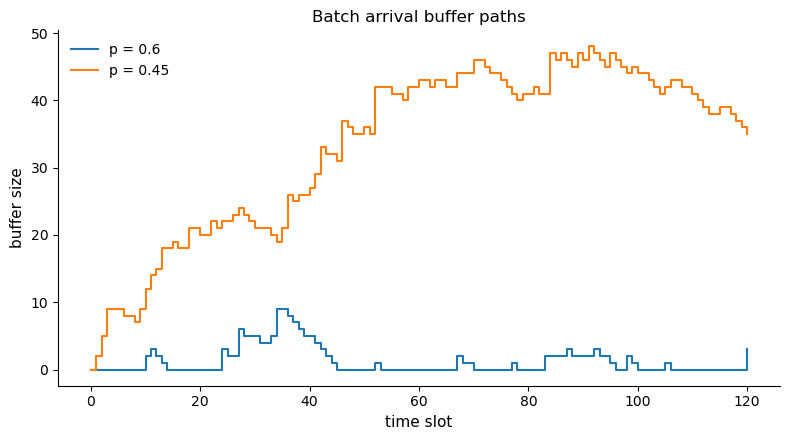

In [19]:
# Number of time slots
n_steps = 120

# Geometric parameters
p_values = [0.6, 0.45]

# Random generator
rng = np.random.default_rng()

plt.figure(figsize=FIGSIZE)

for p in p_values:
    Q_batch = simulate_batch_buffer(
        n_steps,
        p,
        rng
    )

    plt.step(
        np.arange(n_steps + 1),
        Q_batch,
        where="post",
        label=f"p = {p}"
    )

plt.xlabel("time slot")
plt.ylabel("buffer size")
plt.title("Batch arrival buffer paths")
plt.legend()
plt.tight_layout()
plt.show()

Using the same buffer update rule, different arrival parameters can lead to different queue behaviour. Here the only changed parameter is $p$, and smaller values of $p$ produce larger arrival batches on average.

The single paths are only illustrative, but the case $p=0.45$ tends to create more arrivals than the case $p=0.6$. The next task checks this more directly by computing the mean number of arrivals for each value of $p$.


### Task 3

For geometric arrivals on $\{0,1,2,\ldots\}$, the mean number of arrivals in one slot is

$$
E[A]=\frac{1-p}{p}.
$$

Compute this mean for

$$
p=0.6
\qquad\text{and}\qquad
p=0.45.
$$

Then use the result to explain why the buffer path with $p=0.45$ tends to be larger.

In [20]:
# Compute the mean batch size for two geometric parameters.

# Set p1 = 0.6 and p2 = 0.45.

# Compute the mean number of arrivals for each p.


### Solution

For geometric arrivals on $\{0,1,2,\ldots\}$,

$$
E[A]=\frac{1-p}{p}.
$$

A smaller value of $p$ gives a larger expected batch size.

In [21]:
# Solution to Task 3

# Geometric parameters
p1 = 0.6
p2 = 0.45

# Mean number of arrivals
mean_arrivals_p1 = (1 - p1) / p1
mean_arrivals_p2 = (1 - p2) / p2

print("Mean arrivals for p = 0.6:")
print(mean_arrivals_p1)

print()
print("Mean arrivals for p = 0.45:")
print(mean_arrivals_p2)

Mean arrivals for p = 0.6:
0.6666666666666667

Mean arrivals for p = 0.45:
1.2222222222222223


For $p=0.6$, the mean number of arrivals is about $0.67$.

For $p=0.45$, the mean number of arrivals is about $1.22$.

The service capacity is one packet per slot. For $p=0.6$, the mean arrival amount is below this capacity, so the buffer can return to smaller values. For $p=0.45$, the mean arrival amount is above the service capacity, so the buffer has an upward tendency. A single simulated path may still fluctuate, but the mean arrival amount explains the difference in stability.

## Example 5: The continuous time buffer model M/M/1

The discrete time buffer used time slots. We now use a continuous time queue.

In an M/M/1 queue, customers arrive according to a Poisson process with rate $\lambda$. Service times are independent exponential random variables with rate $\mu$. There is one server.

Let

$$
X(t)=\text{number of customers in the system at time }t.
$$

This includes the customer in service and the customers waiting in the queue.

The process is a birth death process. An arrival increases the state by one, and a service completion decreases the state by one. The traffic intensity is

$$
\rho=\frac{\lambda}{\mu}.
$$

When $\rho<1$, the queue has a stationary distribution. When $\rho\geq 1$, the queue does not settle down in the same way.

In [22]:
def simulate_mm1_path(lambda_rate, mu_rate, T_max, rng):
    """
    Simulate one path of an M/M/1 queue.
    """

    times = [0.0]
    states = [0]

    current_time = 0.0
    current_state = 0

    while current_time < T_max:
        # Arrival rate is always lambda_rate
        arrival_rate = lambda_rate

        # Service rate is mu_rate only when the system is non-empty
        if current_state > 0:
            service_rate = mu_rate
        else:
            service_rate = 0.0

        # Total event rate
        total_rate = arrival_rate + service_rate

        # Time to next event
        holding_time = rng.exponential(1 / total_rate)

        # Stop if the next event would occur after T_max
        if current_time + holding_time > T_max:
            break

        current_time = current_time + holding_time

        # Decide whether the next event is an arrival or a service completion
        if rng.random() < arrival_rate / total_rate:
            current_state = current_state + 1
        else:
            current_state = current_state - 1

        times.append(current_time)
        states.append(current_state)

    return np.array(times), np.array(states)

We first compare three traffic intensities.

The service rate is fixed at $\mu=1$. We choose $\lambda$ so that

$$
\rho=0.9,\qquad \rho=1.0,\qquad \rho=1.1.
$$

The purpose is not to estimate a stationary distribution yet. The purpose is to see how the sample path changes when the arrival rate approaches or exceeds the service rate.

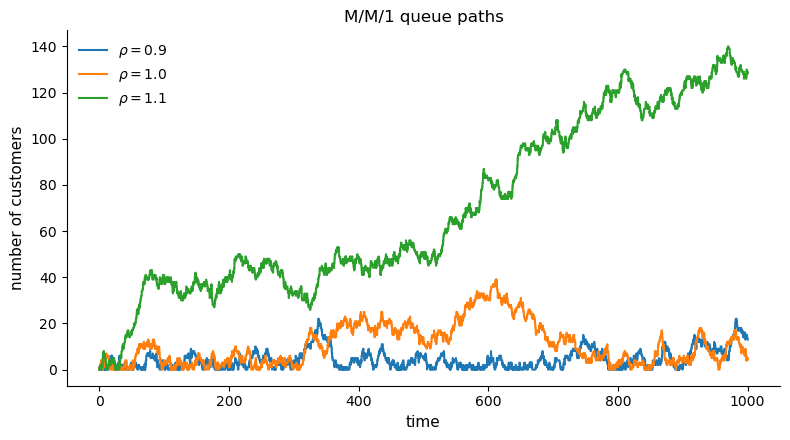

In [23]:
# Time horizon
T_max = 1000

# Service rate
mu_rate = 1.0

# Traffic intensities
rho_values = [0.9, 1.0, 1.1]

# Random generator
rng = np.random.default_rng()

plt.figure(figsize=FIGSIZE)

for rho in rho_values:
    lambda_rate = rho * mu_rate

    times_mm1, states_mm1 = simulate_mm1_path(
        lambda_rate,
        mu_rate,
        T_max,
        rng
    )

    plot_times = np.append(times_mm1, T_max)
    plot_states = np.append(states_mm1, states_mm1[-1])

    plt.step(
        plot_times,
        plot_states,
        where="post",
        label=fr"$\rho={rho}$"
    )

plt.xlabel("time")
plt.ylabel("number of customers")
plt.title("M/M/1 queue paths")
plt.legend()
plt.tight_layout()
plt.show()

The traffic intensity $\rho=\lambda/\mu$ controls the behaviour of the M/M/1 queue. When $\rho=0.9$, arrivals occur slightly less often than services, so the queue fluctuates but tends to return to smaller values.

The case $\rho=1.0$ is critical and can produce long excursions. When $\rho=1.1$, arrivals occur more often than services, so the queue has a stronger tendency to grow. These sample paths illustrate the difference between stable, critical, and unstable queue behaviour.


### Stationary distribution in the stable case

For $\rho<1$, the M/M/1 queue has a stationary distribution

$$
\pi_k=(1-\rho)\rho^k,
\qquad k=0,1,2,\ldots.
$$

This is a geometric distribution on the nonnegative integers.

We now simulate a long path for the stable case $\rho=0.9$ and compare the empirical time spent in each state with the theoretical stationary probabilities.

In [24]:
def empirical_time_distribution(times, states, T_max, max_state):
    """
    Estimate the time distribution of a CTMC path.
    """

    time_in_state = np.zeros(max_state + 1)

    extended_times = np.append(times, T_max)
    holding_times = np.diff(extended_times)

    for state, duration in zip(states, holding_times):
        if state <= max_state:
            time_in_state[state] = time_in_state[state] + duration

    return time_in_state / T_max

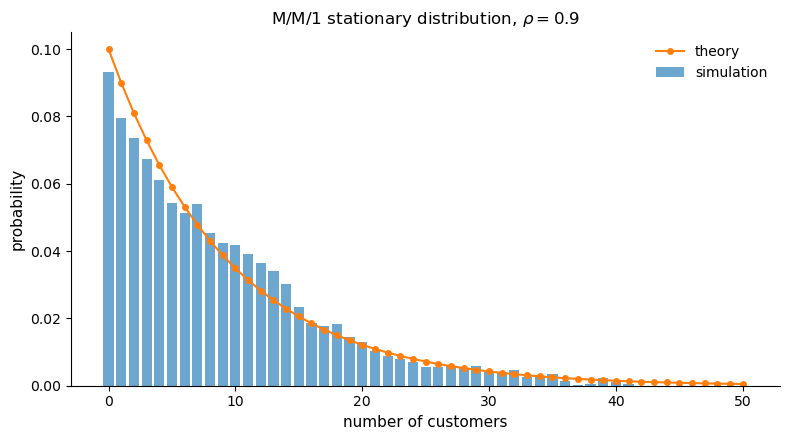

In [25]:
# Stable case
rho = 0.9
mu_rate = 1.0
lambda_rate = rho * mu_rate

# Long time horizon
T_max_long = 5000

# Display states
max_state = 50
states_display = np.arange(max_state + 1)

# Random generator
rng = np.random.default_rng()

# Simulate one long path
times_long, states_long = simulate_mm1_path(
    lambda_rate,
    mu_rate,
    T_max_long,
    rng
)

# Empirical time distribution
pi_empirical = empirical_time_distribution(
    times_long,
    states_long,
    T_max_long,
    max_state
)

# Theoretical stationary distribution
pi_theory = (1 - rho) * rho ** states_display

plt.figure(figsize=FIGSIZE)

plt.bar(
    states_display,
    pi_empirical,
    alpha=HIST_ALPHA,
    label="simulation"
)

plt.plot(
    states_display,
    pi_theory,
    marker="o",
    color="C1",
    label="theory"
)

plt.xlabel("number of customers")
plt.ylabel("probability")
plt.title(r"M/M/1 stationary distribution, $\rho=0.9$")
plt.legend()
plt.tight_layout()
plt.show()

The bars are based on the fraction of time that the simulated path spends in each state. The curve gives the theoretical stationary probabilities.

The comparison uses time spent in states, not just the number of visits. This matters because a continuous time chain may stay in different states for different lengths of time.

For $\rho=0.9$, the empirical distribution is close to the geometric stationary distribution, although there is still simulation noise.